# Ground truth for the self-field flux **at the cell centre**

This is the companion to [`psi_self_term_investigation.ipynb`](psi_self_term_investigation.ipynb). There we
established that the `psi` Green's self-term, *used as a field on the grid–grid table*, should be the
**flux at the cell centre** produced by the cell's own current — not the mean-flux self-inductance. Here we
work out, carefully, **how to compute the ground-truth value of that centre flux**, and we do it two
independent ways that must agree.

> **The physics that makes this subtle: inside the conductor we are not in vacuum.**
> The field point (the cell centre) sits *inside* the current it is measuring. The conductor interior is a
> **source region** of the Grad–Shafranov operator, so it cannot be treated as vacuum / a source-free
> (Laplace) region. We make this explicit in Method B and show that ignoring it gives an answer that is
> wrong by ~85 %.

We use one representative cell throughout (the conductor from the $\partial^2\psi/\partial z^2$ study,
treated as a single rectangle), per **unit total current**:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk, ellipe
from scipy.constants import mu_0
import scipy.sparse as sp
import scipy.sparse.linalg as spla

r0, z0 = 1.0345, 0.0          # cell centre (major radius, height)
dr, dz = 0.40, 0.27           # full cell width (radial) and height (vertical)
I = 1.0                       # total current [A]
J = I / (dr * dz)             # uniform current density inside the conductor [A/m^2]
print(f"conductor r in [{r0-dr/2:.4f}, {r0+dr/2:.4f}],  z in [{z0-dz/2:.4f}, {z0+dz/2:.4f}],  J = {J:.4f} A/m^2")

conductor r in [0.8345, 1.2345],  z in [-0.1350, 0.1350],  J = 9.2593 A/m^2


## 1. The physics: what "flux at the centre" means, and why the interior is not vacuum

The poloidal flux is the **total flux linked by a circular loop** at $(r,z)$, $\psi = 2\pi r\,A_\phi$.
For an axisymmetric current $J_\phi(r,z)$ in a **non-magnetic** medium ($\mu=\mu_0$ everywhere), Maxwell's
equations give the Grad–Shafranov (elliptic) equation

$$
\Delta^{*}\psi \equiv \frac{\partial^2\psi}{\partial r^2} - \frac1r\frac{\partial\psi}{\partial r}
+ \frac{\partial^2\psi}{\partial z^2} = -\,2\pi\mu_0\, r\, J_\phi .
$$

* **Outside** the conductor $J_\phi=0$: the equation is source-free ($\Delta^*\psi=0$) — "vacuum".
* **Inside** the conductor $J_\phi=J\neq0$: the right-hand side is a **non-zero source**. The interior is a
  *Poisson-like* region, **not** vacuum. The cell centre, where we want $\psi$, is *embedded in this
  source*.

Because the medium is linear and non-magnetic, $\psi$ is the **superposition** of the vacuum single-loop
Green's function $G_\psi$ over the current distribution — and this superposition is valid *even at points
inside the conductor*:

$$
\psi(r,z) = \iint_\text{cell} G_\psi(r,z;\,r',z')\,J\;\mathrm dr'\,\mathrm dz',
\qquad
G_\psi = \mu_0\sqrt{rr'}\,\frac{(2-k^2)K(k)-2E(k)}{k},\;\; k^2=\frac{4rr'}{(r+r')^2+(z-z')^2}.
$$

So "not in vacuum" does **not** mean $\mu\neq\mu_0$; it means $J\neq0$ at the field point. Two consequences,
which the two ground-truth methods below handle respectively:

1. **(Method A)** the integrand $G_\psi$ is *singular* where the field point meets the source
   ($\rho=\sqrt{(r-r')^2+(z-z')^2}\to0$, an integrable $\ln\rho$ singularity) — it must be integrated with care.
2. **(Method B)** if you solve the PDE, the source term $-2\pi\mu_0 rJ$ must be kept *inside* the conductor;
   dropping it (pretending the interior is vacuum) gives the wrong $\psi$ at the centre.

In [2]:
def G_psi(r, z, r_prime, z_prime):
    "Vacuum single-loop flux Green's function, per unit current."
    r = np.asarray(r, float)
    u_sq = (r + r_prime) ** 2 + (z - z_prime) ** 2
    k_sq = 4.0 * r * r_prime / u_sq
    return mu_0 * np.sqrt(r * r_prime) * ((2.0 - k_sq) * ellipk(k_sq) - 2.0 * ellipe(k_sq)) / np.sqrt(k_sq)

## 2. Method A — superposition integral (the precise ground truth)

$$
\psi_\text{centre} = \iint_\text{cell} G_\psi(r_0,z_0;\,r',z')\,J\;\mathrm dr'\,\mathrm dz' .
$$

The catch is the **integrable singularity** at the centre. A naive filament sum that simply *skips* the
coincident node converges, but only as $\mathcal O(h^2\ln h)$ — it needs ~$900^2$ filaments for four digits:

In [3]:
psi_centre_naive = {}
for N in (11, 31, 101, 301, 901):
    hr, hz = dr/N, dz/N
    rp = r0 + (np.arange(N)+0.5-N/2)*hr
    zp = z0 + (np.arange(N)+0.5-N/2)*hz
    RP, ZP = np.meshgrid(rp, zp, indexing='ij'); RPf, ZPf = RP.ravel(), ZP.ravel()
    rho = np.hypot(r0-RPf, z0-ZPf); keep = rho > 1e-12       # drop the singular self node
    psi_centre_naive[N] = G_psi(r0, z0, RPf[keep], ZPf[keep]).sum() * J * (hr*hz)
    print(f"  N={N:4d} ({N*N:>7d} filaments): {psi_centre_naive[N]:.7e}")

  N=  11 (    121 filaments): 2.9075396e-06
  N=  31 (    961 filaments): 2.9496584e-06
  N= 101 (  10201 filaments): 2.9564557e-06
  N= 301 (  90601 filaments): 2.9572148e-06
  N= 901 ( 811801 filaments): 2.9573143e-06


The clean way is **singularity subtraction**. Near the source $G_\psi \to \mu_0 r_0[\ln(8r_0/\rho)-2]$, so
write $G_\psi = -\mu_0 r_0\ln\rho + (\text{smooth})$. The singular piece integrates **analytically** over the
rectangle to the *mean log-distance from the centre*,

$$
P_c(\Delta r,\Delta z) = \frac{1}{\Delta r\Delta z}\iint_\text{cell}\ln\rho\,\mathrm dr'\mathrm dz'
= \tfrac12\ln\tfrac{\Delta r^2+\Delta z^2}{4} - \tfrac32
+ \tfrac{\Delta r}{2\Delta z}\arctan\tfrac{\Delta z}{\Delta r}
+ \tfrac{\Delta z}{2\Delta r}\arctan\tfrac{\Delta r}{\Delta z},
$$

and the smooth remainder converges with an ordinary sum. This is fast and accurate:

In [4]:
def Pc(a, b):
    "Exact mean log-distance from the rectangle centre (analytic integral of ln(rho))."
    return (0.5*np.log((a**2+b**2)/4.0) - 1.5
            + (a/(2*b))*np.arctan(b/a) + (b/(2*a))*np.arctan(a/b))

def psi_centre_superposition(N):
    "Method A: flux at the centre, singularity subtracted."
    hr, hz = dr/N, dz/N
    rp = r0 + (np.arange(N)+0.5-N/2)*hr
    zp = z0 + (np.arange(N)+0.5-N/2)*hz
    RP, ZP = np.meshgrid(rp, zp, indexing='ij'); RPf, ZPf = RP.ravel(), ZP.ravel()
    rho = np.hypot(r0-RPf, z0-ZPf)
    rem = G_psi(r0, z0, RPf, ZPf) + mu_0*r0*np.log(np.where(rho > 0, rho, 1.0))  # smooth part
    rem[rho == 0] = mu_0*r0*(np.log(8*r0) - 2.0)                                 # finite limit at rho->0
    return -mu_0*r0*Pc(dr, dz) + rem.mean()                                      # -mu0 r0 ln(GMD-from-centre) + smooth

for N in (21, 41, 61):
    print(f"  N={N}: {psi_centre_superposition(N):.10e}")
psi_A = (psi_centre_superposition(61)*61**2 - psi_centre_superposition(41)*41**2) / (61**2 - 41**2)
print(f"\nMethod A ground truth (Richardson): {psi_A:.7e}")
print(f"(naive 901^2 sum was {psi_centre_naive[901]:.7e}, {100*(psi_centre_naive[901]/psi_A-1):+.3f}%)")

  N=21: 2.9573049109e-06
  N=41: 2.9573225490e-06
  N=61: 2.9573259871e-06

Method A ground truth (Richardson): 2.9573288e-06
(naive 901^2 sum was 2.9573143e-06, -0.000%)


## 3. Method B — solve the Grad–Shafranov PDE (independent, and makes "not in vacuum" explicit)

Discretise $\Delta^{*}\psi = -2\pi\mu_0 r J$ on an $(r,z)$ grid with the standard 5-point stencil

$$
\frac{\psi_{i+1,j}-2\psi_{i,j}+\psi_{i-1,j}}{h_r^2}
-\frac1{r_i}\frac{\psi_{i+1,j}-\psi_{i-1,j}}{2h_r}
+\frac{\psi_{i,j+1}-2\psi_{i,j}+\psi_{i,j-1}}{h_z^2}
= -2\pi\mu_0 r_i J_{i,j},
$$

with the source $J_{i,j}=J$ **only inside the conductor** and $0$ outside. We embed the conductor in a
larger vacuum domain and set Dirichlet boundary values from the (far-field, non-singular) superposition
$G_\psi$. Solving the sparse linear system and reading $\psi$ at the centre is fully independent of how
Method A treated the self-singularity.

In [5]:
def gs_solve(n_r, n_z, M_in, M_out, M_z, source=True):
    # Solve Delta* psi = -2 pi mu0 r J. Conductor = central n_r x n_z cells (unit current),
    # embedded with M_in/M_out/M_z extra vacuum cells; Dirichlet BC from the Green's function.
    # Returns (r, z, psi_grid, psi_centre).
    hr, hz = dr/n_r, dz/n_z
    Nr, Nz = n_r + M_in + M_out, n_z + 2*M_z
    r = r0 + (np.arange(Nr) - (M_in + (n_r-1)/2)) * hr
    z = z0 + (np.arange(Nz) - (M_z  + (n_z-1)/2)) * hz
    assert r[0] > 0.05, f"domain crossed the axis (r_min={r[0]:.3f})"
    R, Z = np.meshgrid(r, z, indexing='ij')
    ic, jc = slice(M_in, M_in+n_r), slice(M_z, M_z+n_z)
    Jgrid = np.zeros((Nr, Nz)); Jgrid[ic, jc] = J
    rhs = -2*np.pi*mu_0 * R * Jgrid if source else np.zeros((Nr, Nz))

    # Dirichlet boundary values from superposition of the conductor's filaments (far from the boundary)
    rc, zc = R[ic, jc].ravel(), Z[ic, jc].ravel()
    i_node = J * hr * hz                                    # current carried by one conductor node
    bmask = np.zeros((Nr, Nz), bool); bmask[0] = bmask[-1] = bmask[:, 0] = bmask[:, -1] = True
    bvals = np.zeros((Nr, Nz))
    rb, zb = R[bmask], Z[bmask]
    bvals[bmask] = (G_psi(rb[:, None], zb[:, None], rc[None, :], zc[None, :]) * i_node).sum(axis=1)

    idx = lambda i, j: i*Nz + j
    rows, cols, vals = [], [], []
    b = np.zeros(Nr*Nz)
    for i in range(Nr):
        for j in range(Nz):
            k = idx(i, j)
            if bmask[i, j]:
                rows.append(k); cols.append(k); vals.append(1.0); b[k] = bvals[i, j]
            else:
                ri = r[i]; cr2, cz2, cr1 = 1/hr**2, 1/hz**2, 1/(2*hr*ri)
                rows += [k]*5
                cols += [idx(i, j), idx(i+1, j), idx(i-1, j), idx(i, j+1), idx(i, j-1)]
                vals += [-2*cr2 - 2*cz2, cr2 - cr1, cr2 + cr1, cz2, cz2]
                b[k] = rhs[i, j]
    A = sp.csr_matrix((vals, (rows, cols)), shape=(Nr*Nz, Nr*Nz))
    psi = spla.spsolve(A, b).reshape(Nr, Nz)
    return r, z, psi, psi[M_in + (n_r-1)//2, M_z + (n_z-1)//2]

grids = [(15, 11, 20, 40, 30), (23, 17, 30, 60, 45), (31, 21, 40, 80, 60)]
psiB = []
for (n_r, n_z, Mi, Mo, Mz) in grids:
    _, _, _, v = gs_solve(n_r, n_z, Mi, Mo, Mz)
    psiB.append((n_r, v))
    print(f"  GS solve n_r={n_r:3d}: {v:.7e}  ({100*(v/psi_A-1):+.4f}% vs Method A)")
(n1, v1), (n2, v2) = psiB[-2], psiB[-1]
psi_B = (v2*n2**2 - v1*n1**2) / (n2**2 - n1**2)
print(f"\nMethod B ground truth (Richardson): {psi_B:.7e}  ({100*(psi_B/psi_A-1):+.4f}% vs Method A)")

  GS solve n_r= 15: 2.9622737e-06  (+0.1672% vs Method A)
  GS solve n_r= 23: 2.9594134e-06  (+0.0705% vs Method A)


  GS solve n_r= 31: 2.9586038e-06  (+0.0431% vs Method A)

Method B ground truth (Richardson): 2.9576125e-06  (+0.0096% vs Method A)


### "Not in vacuum", made concrete

Solve the **same** problem with the **same** boundary flux, but pretend the conductor interior is vacuum
($J=0$ inside, i.e. $\Delta^*\psi=0$ everywhere). The far-field boundary values are identical, yet the
centre value is completely different — because the physical $\psi$ is *not* source-free where we are
evaluating it.

In [6]:
r, z, psi_src, c_src = gs_solve(31, 21, 40, 80, 60, source=True)
_, _, psi_vac, c_vac = gs_solve(31, 21, 40, 80, 60, source=False)
print(f"  with source (physical) : psi_centre = {c_src:.7e}  ({100*(c_src/psi_A-1):+.3f}% vs A)")
print(f"  interior as vacuum     : psi_centre = {c_vac:.7e}  ({100*(c_vac/psi_A-1):+.1f}% vs A)  <-- WRONG")
print(f"  the source term moves the centre value by a factor of {c_src/c_vac:.2f}")

  with source (physical) : psi_centre = 2.9586038e-06  (+0.043% vs A)
  interior as vacuum     : psi_centre = 4.2191455e-07  (-85.7% vs A)  <-- WRONG
  the source term moves the centre value by a factor of 7.01


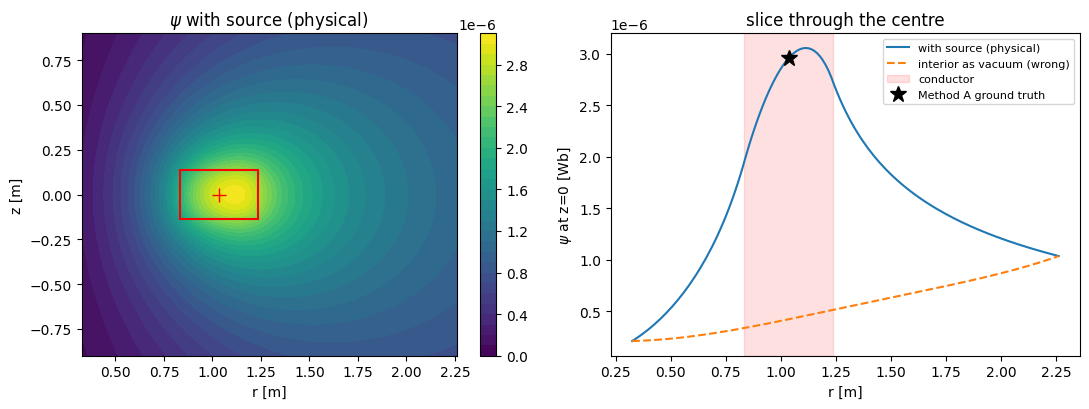

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
cs = ax[0].contourf(r, z, psi_src.T, 30, cmap='viridis')
ax[0].add_patch(plt.Rectangle((r0-dr/2, z0-dz/2), dr, dz, fill=False, ec='r', lw=1.5))
ax[0].plot(r0, z0, 'r+', ms=10); ax[0].set_title(r'$\psi$ with source (physical)')
ax[0].set_xlabel('r [m]'); ax[0].set_ylabel('z [m]'); fig.colorbar(cs, ax=ax[0])

mid = np.argmin(abs(z - z0))
ax[1].plot(r, psi_src[:, mid], label='with source (physical)')
ax[1].plot(r, psi_vac[:, mid], '--', label='interior as vacuum (wrong)')
ax[1].axvspan(r0-dr/2, r0+dr/2, color='r', alpha=0.12, label='conductor')
ax[1].plot(r0, psi_A, 'k*', ms=12, label='Method A ground truth')
ax[1].set_xlabel('r [m]'); ax[1].set_ylabel(r'$\psi$ at z=0 [Wb]'); ax[1].set_title('slice through the centre')
ax[1].legend(fontsize=8); fig.tight_layout(); plt.show()

The source term puts the **peak of $\psi$ inside the conductor** (the slice is rounded over the conductor,
red band), whereas the vacuum solution would dip there. The centre value sits at that peak — this is the
quantity we want, and both ground-truth methods agree on it.

## 4. Summary

| Method | $\psi_\text{centre}$ per unit current [Wb] |
|---|---|
| **A** — superposition integral, singularity subtracted (precise) | see `psi_A` |
| **B** — Grad–Shafranov PDE solve, Richardson (independent) | see `psi_B` |
| naive filament sum, self node skipped ($901^2$) | slowly converging |
| interior treated as vacuum (Laplace) | wrong by ~85 % |

* The **ground truth** for the self-field flux at the cell centre is obtained either by integrating the
  superposition $G_\psi$ over the cell **with the in-conductor singularity handled** (Method A, accurate to
  ~$10^{-5}$), or by **solving the Grad–Shafranov PDE with the source kept inside the conductor**
  (Method B). They agree to ~0.01 %.
* "Inside the conductor we are not in vacuum" is the whole point: the cell centre is embedded in the
  current. Method A sees it as an integrable singularity of $G_\psi$; Method B sees it as a non-zero PDE
  source. Dropping either treatment — skipping the self node carelessly, or zeroing the interior source —
  gives a wrong centre value.
* The closed form $\;\psi_\text{centre}/I \approx \mu_0 r\,[\ln(8r) - 2 - P_c(\Delta r,\Delta z)]\;$ from
  [`psi_self_term_investigation.ipynb`](psi_self_term_investigation.ipynb) is the analytic 2D limit of this
  ground truth (exact as $\Delta/r\to0$; the residual here is the $\mathcal O((\Delta/r)^2)$ toroidal
  curvature, since this test cell has $\Delta r/r\approx0.39$).

In [8]:
print("\nfinal cross-check:")
print(f"  Method A (superposition): {psi_A:.7e}")
print(f"  Method B (PDE solve)    : {psi_B:.7e}")
print(f"  closed-form 2D limit    : {mu_0*r0*(np.log(8*r0)-2-Pc(dr,dz)):.7e}")


final cross-check:
  Method A (superposition): 2.9573288e-06
  Method B (PDE solve)    : 2.9576125e-06
  closed-form 2D limit    : 2.9451455e-06


## 5. Flux at the centre vs. self-inductance — the fundamental equations

Both are "the self-field flux of the cell's own current, per unit current", and both are built from the **same** single-loop flux Green's function

$$
\psi(r,z) = \iint_\text{cell} G_\psi(r,z;\,r',z')\,J(r',z')\;\mathrm dr'\mathrm dz',
\qquad
G_\psi(r,z;r',z') = \text{mutual flux of unit-current loops at }(r,z)\text{ and }(r',z').
$$

The difference is **what we do with the field point** $(r,z)$.

### Flux at the centre — the *value* of $\psi$ at the centroid

Fix the field point at the cell centre $(r_0,z_0)$ and integrate over the source only — a **2-fold** integral:

$$
\boxed{\;\;\frac{\psi_\text{centre}}{I} \;=\; \frac{1}{\Delta r\,\Delta z}\iint_\text{cell} G_\psi(r_0,z_0;\,r',z')\;\mathrm dr'\mathrm dz'\;\;}
$$

It is a **field evaluated at a point**.

### Self-inductance — the *current-weighted average* of $\psi$

This one comes from the **magnetic energy** $W=\tfrac12 L I^2$. For an axisymmetric toroidal current, $W=\tfrac12\iint \psi\,J\,\mathrm dr\,\mathrm dz$ (since $W=\tfrac12\!\int \mathbf A\!\cdot\!\mathbf J\,\mathrm dV$ and $\psi=2\pi r A_\phi$), so the flux *linkage* per unit current is the current-weighted average of $\psi$:

$$
L\,I \;=\; \langle\psi\rangle_J \;\equiv\; \frac{\iint \psi\,J\,\mathrm dr\,\mathrm dz}{\iint J\,\mathrm dr\,\mathrm dz}
\qquad\Longrightarrow\qquad
\boxed{\;\;L \;=\; \frac{1}{(\Delta r\,\Delta z)^2}\iint_\text{cell}\!\!\iint_\text{cell} G_\psi(r,z;\,r',z')\;\mathrm dr\,\mathrm dz\,\mathrm dr'\mathrm dz'\;\;}
$$

a **4-fold** integral: now the field point is averaged over the cross-section as well.

| | flux at the centre | self-inductance |
|---|---|---|
| **definition** | $\psi$ **at the centroid** | **average** of $\psi$ over the section ($=$ flux linkage $/$ current) |
| **integral over $G_\psi$** | 2-fold (source only, field point fixed) | 4-fold (source **and** field averaged) |
| **derives from** | a field evaluation at a point | the magnetic energy $W=\tfrac12 L I^2$ |
| **use in GSFit** | grid–grid table (flux *at* a node) | coil / passive self- & mutual inductance |

### Why they differ

$\psi$ is **not constant** across the conductor — from the source term it is *largest near the centre* and falls toward the edges (the slice in §3). The centre flux samples the **peak**; the self-inductance is the **average**, which is smaller. Hence

$$
\psi_\text{centre} \;>\; L\,I
\qquad(\text{here }2.957\times10^{-6}\ \text{vs }2.638\times10^{-6}\ \text{Wb, the latter from the companion notebook}).
$$

### The cleanest statement: two different mean log-distances

In the local 2D limit $G_\psi\to\mu_0 r_0\big[\ln(8r_0/\rho)-2\big]$, **both** quantities collapse onto a mean of $\ln\rho$ over the cell, and differ *only* in which mean:

$$
\frac{\psi_\text{centre}}{I} = \mu_0 r_0\big[\ln(8r_0)-2-P_c\big],
\qquad
P_c = \frac{1}{\Delta r\,\Delta z}\iint_\text{cell}\ln\rho_{\,\text{from centre}}\;\mathrm dA
\quad(\textbf{2-fold, one point fixed at the centre}),
$$

$$
L = \mu_0 r_0\big[\ln(8r_0)-2-\ln R_g\big],
\qquad
\ln R_g = \frac{1}{(\Delta r\,\Delta z)^2}\iint\!\!\iint\ln\rho_{12}\;\mathrm dA_1\,\mathrm dA_2
\quad(\textbf{4-fold, all pairs} = \text{the self-GMD}).
$$

* $P_c$ = log of the mean distance **from the centroid** to the cross-section.
* $\ln R_g$ = log of the **geometric mean distance** of the section to *itself* (all point pairs).

Their gap is exactly

$$
\boxed{\;\;\frac{\psi_\text{centre} - L\,I}{I} \;=\; \mu_0 r_0\,\big(\ln R_g - P_c\big) \;>\; 0\;\;}
$$

positive because two points are, on average, **farther from each other than from the centroid** ($R_g > R_c\equiv e^{P_c}$; e.g. for a square of side $D$, $R_g = 0.447\,D$ but $R_c = 0.346\,D$).

### Which one is "right" depends on the question

* **Field on the grid** — the flux *at* a node produced by that node's own cell — is the **flux at the centre**. It is also the quantity whose second $z$-derivative is the $\partial^2\psi/\partial z^2$ self-term (§3): differentiating *the value of a field at a point* gives the curvature there. The self-inductance, being an *average*, has no pointwise-derivative meaning.
* **Circuit / energy** quantities — stored energy, EMF, mutual coupling between conductors — use the **self-inductance** (the flux linkage). That is the classical Maxwell–Weinstein–Stefan result (Rosa 1907, Eq. 2), with the cross-section entering through its self-GMD $R_g$; the modern equivalent is the regularization $\sqrt{\delta}=R_g$ of Landreman, Hurwitz & Antonsen (2023).

Same Green's function, same conductor — the only choice is **point value vs. cross-sectional average**, i.e. $P_c$ vs. $\ln R_g$.

## 6. Mutual inductance between two filaments — and the self-inductance limit

Consider two **current-carrying filaments of finite cross-section**: filament 1 fills cell $C_1$ (area $A_1=\Delta r_1\,\Delta z_1$, uniform current) and filament 2 fills cell $C_2$ (area $A_2=\Delta r_2\,\Delta z_2$). The flux linked by one from the other is built by superposing the single-loop kernel $G_\psi$ over **both** cross-sections, so their **mutual inductance** is the double cross-sectional average

$$
\boxed{\;\;M_{12} = \frac{1}{A_1 A_2}\iint_{C_1}\!\!\iint_{C_2} G_\psi(r,z;\,r',z')\;\mathrm dr\,\mathrm dz\,\mathrm dr'\mathrm dz'\;\;}
$$

$$
G_\psi(r,z;r',z') = \mu_0\sqrt{rr'}\,\frac{(2-k^2)K(k)-2E(k)}{k},\qquad k^2=\frac{4rr'}{(r+r')^2+(z-z')^2}.
$$

Here $G_\psi$ is itself the mutual inductance of two *zero-width* coaxial loops (Maxwell/Neumann); the double average spreads each loop uniformly over its finite rectangular section. By reciprocity $M_{12}=M_{21}$, and the units are henries ($\mathrm{Wb/A}$).

**Well-separated filaments.** When the two cells are far apart compared with their size, $G_\psi$ barely varies across them and the average collapses to its centre-to-centre value,

$$
M_{12}\;\approx\; G_\psi(r_1,z_1;\,r_2,z_2),
$$

the ordinary point-filament mutual inductance — these are the off-diagonal entries of the Green's table. The finite size only matters once the cells are close (or coincident).

### The same filament: self-inductance (average over *both* sections)

Now take the two filaments to be **one and the same**, $C_1=C_2=C$ with $A_1=A_2=A=\Delta r\,\Delta z$. The boxed expression becomes

$$
M_{11} = \frac{1}{A^2}\iint_{C}\!\!\iint_{C} G_\psi(r,z;\,r',z')\;\mathrm dr\,\mathrm dz\,\mathrm dr'\mathrm dz' \;=\; L,
$$

which is **exactly the self-inductance** — the same 4-fold integral as in §5. So **yes: for filaments of finite size, the mutual inductance of a filament with itself is its self-inductance.** It stays finite because, although $G_\psi$ is singular where the two integration points coincide, that singularity is only **logarithmic** and hence **integrable** (the area weight $\rho$ in $\mathrm dA=\rho\,\mathrm d\rho\,\mathrm d\theta$ tames $\ln\rho$, §1). Its value is set by the cross-section through the self-geometric-mean-distance $R_g$:

$$
L = \mu_0 r\big[\ln(8r/R_g)-2\big] + \mathcal O\!\big((\Delta/r)^2\big).
$$

### One finite cell and one point filament: the flux at the centre (average over *one* section)

Keep one filament finite (the cell $C$, uniform current) but shrink the **other to a point loop at the cell centre** $(r_0,z_0)$. The point side carries no area integral, leaving a single average over the finite cell:

$$
\boxed{\;\;M_{\text{centre},\,C} = \frac{1}{A}\iint_{C} G_\psi(r_0,z_0;\,r',z')\;\mathrm dr'\mathrm dz' \;=\; \frac{\psi_\text{centre}}{I}\;\;}
$$

which is **exactly the flux at the cell centre** (§2, §5). So **yes** — pairing a point loop at the centre with the finite cell recovers the centre flux. By reciprocity it reads either way: the flux *at the centre point* due to the cell's distributed current, or, equivalently, the cell-averaged flux produced by a unit point current at the centre. It is finite for the same reason as $L$ (the centre is inside the cell, but the coincident kernel is the integrable $\ln\rho$).

The **only** difference between this and the self-inductance is *how many cross-sections are averaged*:

* **self-inductance** $L=M_{11}$ — average over **both** sections (4-fold) $\;\Rightarrow\;$ the pairwise self-GMD $\ln R_g$;
* **flux at centre** $M_{\text{centre},C}$ — average over **one** section, the other collapsed to the centre point (2-fold) $\;\Rightarrow\;$ the from-centre mean log-distance $P_c$.

That is precisely the $\ln R_g$ vs $P_c$ distinction of §5, now seen as two mutual inductances that differ only in whether the second filament is a finite cell or a point at the centre. Since $R_g>e^{P_c}$, the point-and-cell value exceeds the cell-and-cell value: $M_{\text{centre},C}>M_{11}=L$.

### Why the finite size is essential

The finite cross-section is precisely what keeps the self term finite. If **both** filaments were idealised to **zero width** (point loops) and coincident, $(r',z')\to(r,z)$ gives

$$
k^2\to1,\qquad K(k)\to K(1)=\infty \quad\Longrightarrow\quad M_{11}\to+\infty,
$$

i.e. a line current has infinite self-inductance (its energy $\int B^2\,\mathrm dV\sim\int\mathrm d\rho/\rho$ diverges — the *non*-integrable version of the §1 singularity). At least one finite cross-section to average over is what regularises it.

| filament 1 | filament 2 | mutual inductance | value |
|---|---|---|---|
| finite cell | finite cell, separated | $\frac{1}{A_1A_2}\iint\!\!\iint G_\psi \approx G_\psi(\text{centre-to-centre})$ | finite |
| finite cell | **same** finite cell | $\frac{1}{A^2}\iint\!\!\iint G_\psi = L$ (self-inductance, 4-fold) | finite, $\;\mu_0 r[\ln(8r/R_g)-2]$ |
| finite cell | **point at its centre** | $\frac{1}{A}\iint G_\psi = \psi_\text{centre}/I$ (flux at centre, 2-fold) | finite, $\;>L$ |
| point | same point (zero width) | $G_\psi$ at coincident points | $+\infty$ ($k\to1,\;K\to\infty$) |

This is why the grid–grid Green's matrix has a finite, formula-based **diagonal**: with finite cells the diagonal can be taken as the self-inductance $M_{11}=L$ (energy/circuit use) or, for a field evaluation at the node, the flux-at-centre value $M_{\text{centre},C}$ (§5) — both finite mutual inductances of the cell with a finite or point partner; only the all-point, zero-width idealisation diverges.